In [ ]:
import torch
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
root_cub = os.path.join("experiments", "scbm_residual", "CUB")

# # 50 residuals
EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02")

# # 20 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5")

# 5 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-07-31_20-15-47_496cf")



## Dataset information

In [ ]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [ ]:
# Read dataset dir from the log file in the experiment path
import ast


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
df.to_csv("delete_afterwards/concept_names_new_idx_map.csv", index=False)
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")





,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


### Check that the attribute groups in the above df is the same as the attribute groups kept for data generation

This is a security check


In [ ]:
# Check if the concept name in the df matches the attribute groups that were used: attr_groups_unique
attr_groups_from_df = df["Concept Name"].apply(lambda name: name.split("::")[0])

attr_groups_from_df = list(attr_groups_from_df.unique())


kept_attr_groups_from_info = [group for group in attr_groups__112_concepts if group not in removed_attribute_groups]

# Check if the kept attribute groups from the info file match the attribute groups from the df
print(f"same attribute groups: {set(kept_attr_groups_from_info) == set(attr_groups_from_df)}")


same attribute groups: True


### Missing concepts 

In [ ]:
missing_concept_names = [sample_112_concepts_map[orig_idx] for orig_idx in range(112) if orig_idx not in new_attribute_mapping.keys()]
print(missing_concept_names)

['has_wing_color::brown', 'has_wing_color::grey', 'has_wing_color::yellow', 'has_wing_color::black', 'has_wing_color::white', 'has_wing_color::buff', 'has_upperparts_color::brown', 'has_upperparts_color::grey', 'has_upperparts_color::yellow', 'has_upperparts_color::black', 'has_upperparts_color::white', 'has_upperparts_color::buff', 'has_underparts_color::brown', 'has_underparts_color::grey', 'has_underparts_color::yellow', 'has_underparts_color::black', 'has_underparts_color::white', 'has_underparts_color::buff', 'has_breast_pattern::solid', 'has_breast_pattern::striped', 'has_breast_pattern::multi-colored', 'has_back_color::brown', 'has_back_color::grey', 'has_back_color::yellow', 'has_back_color::black', 'has_back_color::white', 'has_back_color::buff', 'has_tail_shape::notched_tail', 'has_upper_tail_color::brown', 'has_upper_tail_color::grey', 'has_upper_tail_color::black', 'has_upper_tail_color::white', 'has_upper_tail_color::buff', 'has_throat_color::grey', 'has_throat_color::yell

Use this to check if some residuals get more activated with some hidden concepts

### Accuracy and AUROC for different bird classes

In [ ]:
class_name = {}

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "CUB_200_2011", "classes.txt"), 'r') as f:
    lines = f.readlines()
    for line in lines:
        idx, class_name_str = line.strip().split(" ")
        class_name[int(idx) - 1] = class_name_str
        
print(class_name)

{0: '001.Black_footed_Albatross', 1: '002.Laysan_Albatross', 2: '003.Sooty_Albatross', 3: '004.Groove_billed_Ani', 4: '005.Crested_Auklet', 5: '006.Least_Auklet', 6: '007.Parakeet_Auklet', 7: '008.Rhinoceros_Auklet', 8: '009.Brewer_Blackbird', 9: '010.Red_winged_Blackbird', 10: '011.Rusty_Blackbird', 11: '012.Yellow_headed_Blackbird', 12: '013.Bobolink', 13: '014.Indigo_Bunting', 14: '015.Lazuli_Bunting', 15: '016.Painted_Bunting', 16: '017.Cardinal', 17: '018.Spotted_Catbird', 18: '019.Gray_Catbird', 19: '020.Yellow_breasted_Chat', 20: '021.Eastern_Towhee', 21: '022.Chuck_will_Widow', 22: '023.Brandt_Cormorant', 23: '024.Red_faced_Cormorant', 24: '025.Pelagic_Cormorant', 25: '026.Bronzed_Cowbird', 26: '027.Shiny_Cowbird', 27: '028.Brown_Creeper', 28: '029.American_Crow', 29: '030.Fish_Crow', 30: '031.Black_billed_Cuckoo', 31: '032.Mangrove_Cuckoo', 32: '033.Yellow_billed_Cuckoo', 33: '034.Gray_crowned_Rosy_Finch', 34: '035.Purple_Finch', 35: '036.Northern_Flicker', 36: '037.Acadian_Fl

In [ ]:
# Per class calculate accuracy, count, and ratio for train and test splits
splits = ["train", "test"]
split_data = {}
for split_name in splits:
    y_true_split = torch.load(os.path.join(EXPERIMENT_PATH, split_name, "y_true.pt"))
    y_pred_logits_split = torch.load(os.path.join(EXPERIMENT_PATH, split_name, "y_pred.pt"))
    y_pred_split = y_pred_logits_split.argmax(dim=-1)
    split_data[split_name] = (y_true_split, y_pred_split)
    print(split_name, y_true_split.shape, y_pred_split.shape)
    print(f"Overall {split_name} accuracy:", (y_true_split == y_pred_split).float().mean().item())

# Keep test tensors as the global y_true/y_pred for downstream cells
y_true, y_pred = split_data["test"]
print(y_pred[:5])

# Per class accuracy
class_with_lowest_acc = None
lowest_acc = float('inf')

dict_df = {}

for i in range(200):  # Assuming 200 classes
    row = {"class": i, "class_name": class_name[i]}
    for split_name in splits:
        y_true_split, y_pred_split = split_data[split_name]
        mask = y_true_split == i
        total_samples = y_true_split.size(0)
        class_count = mask.sum().item()
        class_ratio = class_count / total_samples
        class_accuracy = (y_true_split[mask] == y_pred_split[mask]).float().mean().item() if class_count > 0 else float('nan')
        row[f"{split_name}_count"] = class_count
        row[f"{split_name}_ratio"] = class_ratio
        row[f"{split_name}_accuracy"] = class_accuracy
    dict_df[i] = row
    if row["test_count"] > 0 and row["test_accuracy"] < lowest_acc:
        lowest_acc = row["test_accuracy"]
        class_with_lowest_acc = i

class_metric_df = pd.DataFrame.from_dict(dict_df, orient='index')
class_metric_df.to_csv("delete_afterwards/class_metric_df.csv", index=False)
display(class_metric_df)
print(f"Class with lowest test accuracy: {class_with_lowest_acc} with accuracy {lowest_acc}")


train torch.Size([4796]) torch.Size([4796])
Overall train accuracy: 0.9170141816139221
test torch.Size([5794]) torch.Size([5794])
Overall test accuracy: 0.6803590059280396
tensor([2, 0, 0, 0, 0])


,class,class_name,train_count,train_ratio,train_accuracy,test_count,test_ratio,test_accuracy
0,0,001.Black_footed_Albatross,26,0.005421,0.884615,30,0.005178,0.700000
1,1,002.Laysan_Albatross,22,0.004587,1.000000,30,0.005178,0.533333
2,2,003.Sooty_Albatross,23,0.004796,0.913043,28,0.004833,0.678571
3,3,004.Groove_billed_Ani,24,0.005004,0.916667,30,0.005178,0.533333
4,4,005.Crested_Auklet,23,0.004796,1.000000,14,0.002416,0.642857
...,...,...,...,...,...,...,...,...
195,195,196.House_Wren,25,0.005213,0.840000,30,0.005178,0.666667
196,196,197.Marsh_Wren,24,0.005004,0.916667,30,0.005178,0.633333
197,197,198.Rock_Wren,24,0.005004,1.000000,30,0.005178,0.633333
198,198,199.Winter_Wren,26,0.005421,0.884615,30,0.005178,0.833333


Class with lowest test accuracy: 143 with accuracy 0.10000000149011612


In [ ]:
# Check what is predicted instead of the correct class with lowest accuracy
print(f"Class with lowest accuracy: {class_with_lowest_acc} ({class_name[class_with_lowest_acc]}) with accuracy {lowest_acc}")

mask = y_true == class_with_lowest_acc

predicted_classes, counts = torch.unique(
    y_pred[mask],
    return_counts=True,
)

for pred, count in zip(predicted_classes, counts):
    print(f"Predicted {class_name[pred.item()]}: {count.item()}")
    
    
# Top 1 predicted class for the class with lowest accuracy
top1_predicted_class = predicted_classes[counts.argmax()].item()
print(top1_predicted_class)

# Print top predicted classes for this class
print(f"Predicted classes for {top1_predicted_class} ({class_name[top1_predicted_class]}):")
mask = y_true == top1_predicted_class
predicted_classes, counts = torch.unique(
    y_pred[mask],
    return_counts=True,
)

for pred, count in zip(predicted_classes, counts):
    print(f"Predicted {class_name[pred.item()]}: {count.item()}")



Class with lowest accuracy: 143 (144.Common_Tern) with accuracy 0.10000000149011612
Predicted 071.Long_tailed_Jaeger: 1
Predicted 141.Artic_Tern: 10
Predicted 143.Caspian_Tern: 4
Predicted 144.Common_Tern: 3
Predicted 145.Elegant_Tern: 1
Predicted 146.Forsters_Tern: 10
Predicted 147.Least_Tern: 1
140
Predicted classes for 140 (141.Artic_Tern):
Predicted 141.Artic_Tern: 23
Predicted 143.Caspian_Tern: 1
Predicted 144.Common_Tern: 1
Predicted 145.Elegant_Tern: 1
Predicted 146.Forsters_Tern: 3


## Covariance for different classes

test split: 30 samples of class 9 (010.Red_winged_Blackbird)
per-sample covariance shape: (5794, 72, 72) -> averaged: (72, 72)


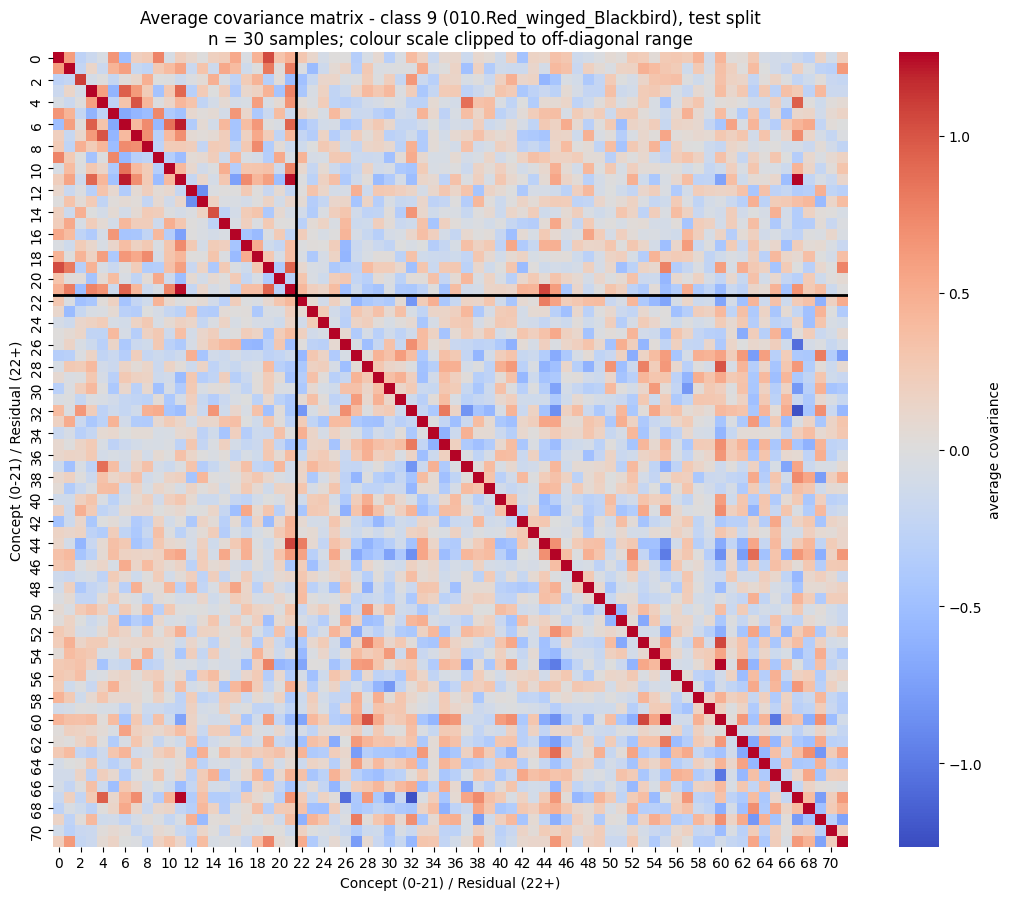

In [ ]:
# Average covariance matrix (concepts + residuals) for a single class
import matplotlib.pyplot as plt
import seaborn as sns

split = "test"
class_idx = 9
class_label = class_name[class_idx]  # keep `class_name` as the full dict so this cell stays re-runnable
NUM_CONCEPTS_COV = 22

y_true_cov = torch.load(os.path.join(EXPERIMENT_PATH, split, "y_true.pt"))
cov_matrices = torch.load(os.path.join(EXPERIMENT_PATH, split, "covariance_matrices.pt"))

class_mask = y_true_cov == class_idx
class_cov = cov_matrices[class_mask]
avg_cov = class_cov.mean(dim=0).numpy()

print(f"{split} split: {int(class_mask.sum())} samples of class {class_idx} ({class_label})")
print("per-sample covariance shape:", tuple(cov_matrices.shape), "-> averaged:", avg_cov.shape)

# Symmetric colour scale around 0, ignoring the (much larger) diagonal variances
off_diag = avg_cov[~np.eye(avg_cov.shape[0], dtype=bool)]
vmax = np.abs(off_diag).max()

plt.figure(figsize=(11, 9))
sns.heatmap(
    avg_cov,
    cmap="coolwarm",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    square=True,
    cbar_kws={"label": "average covariance"},
)
plt.axhline(NUM_CONCEPTS_COV, color="black", linewidth=2)
plt.axvline(NUM_CONCEPTS_COV, color="black", linewidth=2)
plt.title(f"Average covariance matrix - class {class_idx} ({class_label}), {split} split\n"
          f"n = {int(class_mask.sum())} samples; colour scale clipped to off-diagonal range")
plt.xlabel("Concept (0-21) / Residual (22+)")
plt.ylabel("Concept (0-21) / Residual (22+)")
plt.tight_layout()
plt.show()


## Baseline upper bound

In [ ]:
missing_concepts_idx = [idx for idx in range(112) if idx not in new_attribute_mapping.keys()]
print(f"{len(missing_concepts_idx)} missing (hidden) concepts out of 112")
print(missing_concepts_idx)

90 missing (hidden) concepts out of 112
[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 45, 46, 47, 48, 49, 50, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 78, 79, 80, 81, 82, 83, 84, 85, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111]


In [ ]:
# Supervised upper bound: how much of each *missing* (hidden) concept is linearly readable
# from the residual channel? One logistic-regression probe per missing concept, fit on the
# train split's binarized (p > 0.5) residuals and evaluated on the held-out test split. The 22 kept
# concepts and the full 42-dim vector are probed the same way as references.
#
# Ground truth for the missing concepts is not in the 22-concept "incomplete" pkl, so the
# labels come from the full 112-concept pkl (`class_attr_data_10`), which has the same
# samples in the same order (asserted below via `id`).

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import matplotlib.pyplot as plt

NUM_CONCEPTS = 22
FULL_DATA_DIR = os.path.join("datasets", "CUB", "class_attr_data_10")
INCOMPLETE_DATA_DIR = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025")
# Train logits come from the deterministic (test-time) transform so the probe is fit and
# evaluated on the same kind of input -- see the train/test logit distribution section.
PROBE_SPLITS = {"train": "train", "test": "test"}

missing_concepts_idx = [idx for idx in range(112) if idx not in new_attribute_mapping.keys()]
print(f"{len(missing_concepts_idx)} missing (hidden) concepts out of 112")

probe_logits, probe_probabilities, probe_binary, probe_c_true_112 = {}, {}, {}, {}
for probe_split, folder in PROBE_SPLITS.items():
    probe_logits[probe_split] = torch.load(
        os.path.join(EXPERIMENT_PATH, folder, "concepts_residuals_logits_mean.pt")
    ).numpy()
    probe_probabilities[probe_split] = torch.load(
        os.path.join(EXPERIMENT_PATH, folder, "concepts_residuals_pred_probs_mean.pt")
    ).numpy()
    probe_binary[probe_split] = probe_probabilities[probe_split] > 0.5
    
    full_pkl = pd.read_pickle(os.path.join(FULL_DATA_DIR, f"{probe_split}.pkl"))
    inc_pkl = pd.read_pickle(os.path.join(INCOMPLETE_DATA_DIR, f"{probe_split}.pkl"))
    assert [s["id"] for s in full_pkl] == [s["id"] for s in inc_pkl], f"{probe_split}: sample order mismatch"
    assert len(full_pkl) == probe_logits[probe_split].shape[0], f"{probe_split}: n mismatch"
    probe_c_true_112[probe_split] = np.array([s["attribute_label"] for s in full_pkl])
    print(f"{probe_split:5s}: logits {probe_logits[probe_split].shape}, "
          f"112-concept labels {probe_c_true_112[probe_split].shape}")

# Residual-only is the object of interest; the other two blocks are references
FEATURE_BLOCKS = {
    "residual": slice(NUM_CONCEPTS, None),
    "concept": slice(0, NUM_CONCEPTS),
    "concept+residual": slice(None),
}

probe_rows = []
for concept_idx_112 in missing_concepts_idx:
    y_probe = {s: probe_c_true_112[s][:, concept_idx_112] for s in PROBE_SPLITS}
    if any(len(np.unique(y_probe[s])) < 2 for s in PROBE_SPLITS):
        continue  # no variation in one of the splits -> AUC undefined
    row = {
        "concept_idx_112": concept_idx_112,
        "concept_name": sample_112_concepts_map[concept_idx_112],
        "train_pos_rate": y_probe["train"].mean(),
        "test_pos_rate": y_probe["test"].mean(),
    }
    for block_name, cols in FEATURE_BLOCKS.items():
        probe = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=5000, C=1.0, class_weight="balanced"),
        ).fit(probe_binary["train"][:, cols], y_probe["train"])
        for probe_split in PROBE_SPLITS:
            scores = probe.predict_proba(probe_binary[probe_split][:, cols])[:, 1]
            row[f"{block_name}_{probe_split}_auc"] = roc_auc_score(y_probe[probe_split], scores)
        row[f"{block_name}_test_bal_acc"] = balanced_accuracy_score(
            y_probe["test"], probe.predict(probe_binary["test"][:, cols])
        )
    probe_rows.append(row)

missing_probe_df = (
    pd.DataFrame(probe_rows).sort_values("residual_test_auc", ascending=False).reset_index(drop=True)
)
missing_probe_df["residual_minus_concept_auc"] = (
    missing_probe_df["residual_test_auc"] - missing_probe_df["concept_test_auc"]
)
missing_probe_df.to_csv("delete_afterwards/missing_concept_probe_df.csv", index=False)

print(f"\n{len(missing_probe_df)} missing concepts with both classes present in train and test")
print("\nMean test AUC over missing concepts:")
print(missing_probe_df[[f"{b}_test_auc" for b in FEATURE_BLOCKS]].mean().to_string())
print(f"\nresidual test AUC > 0.7: {(missing_probe_df['residual_test_auc'] > 0.7).sum()} / {len(missing_probe_df)}"
      f"   > 0.9: {(missing_probe_df['residual_test_auc'] > 0.9).sum()} / {len(missing_probe_df)}")
display(missing_probe_df)


90 missing (hidden) concepts out of 112
train: logits (4796, 72), 112-concept labels (4796, 112)
test : logits (5794, 72), 112-concept labels (5794, 112)

90 missing concepts with both classes present in train and test

Mean test AUC over missing concepts:
residual_test_auc            0.901009
concept_test_auc             0.872818
concept+residual_test_auc    0.918616

residual test AUC > 0.7: 90 / 90   > 0.9: 53 / 90


,concept_idx_112,concept_name,train_pos_rate,test_pos_rate,residual_train_auc,residual_test_auc,residual_test_bal_acc,concept_train_auc,concept_test_auc,concept_test_bal_acc,concept+residual_train_auc,concept+residual_test_auc,concept+residual_test_bal_acc,residual_minus_concept_auc
0,81,has_shape::duck-like,0.050667,0.049361,0.999850,0.993989,0.957954,0.992556,0.974760,0.918094,0.999972,0.993491,0.959793,0.019229
1,92,has_primary_color::yellow,0.127815,0.128064,0.990287,0.978920,0.943338,0.975142,0.972587,0.936218,0.993554,0.982012,0.944959,0.006333
2,50,has_eye_color::black,0.958716,0.965827,0.996385,0.977606,0.916920,0.977177,0.946955,0.891794,0.999759,0.976903,0.881449,0.030651
3,79,has_size::medium_(9_-_16_in),0.187031,0.181395,0.988377,0.976935,0.941049,0.973354,0.962687,0.911086,0.995254,0.978901,0.938498,0.014248
4,72,has_belly_color::yellow,0.148040,0.148775,0.991299,0.976298,0.944775,0.984855,0.976433,0.936036,0.995409,0.981536,0.947029,-0.000135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,111,has_wing_pattern::multi-colored,0.219141,0.223507,0.841859,0.804348,0.728929,0.799622,0.762418,0.694949,0.900341,0.836163,0.757284,0.041930
86,13,has_upperparts_color::black,0.411384,0.405592,0.829365,0.803264,0.733053,0.823188,0.777611,0.705318,0.908450,0.847511,0.767996,0.025653
87,83,has_back_pattern::solid,0.495621,0.495513,0.842808,0.802672,0.716494,0.824268,0.795285,0.719222,0.903511,0.839474,0.764447,0.007386
88,96,has_leg_color::grey,0.226647,0.215740,0.831824,0.801466,0.730559,0.733775,0.719070,0.644681,0.891123,0.842532,0.769349,0.082397


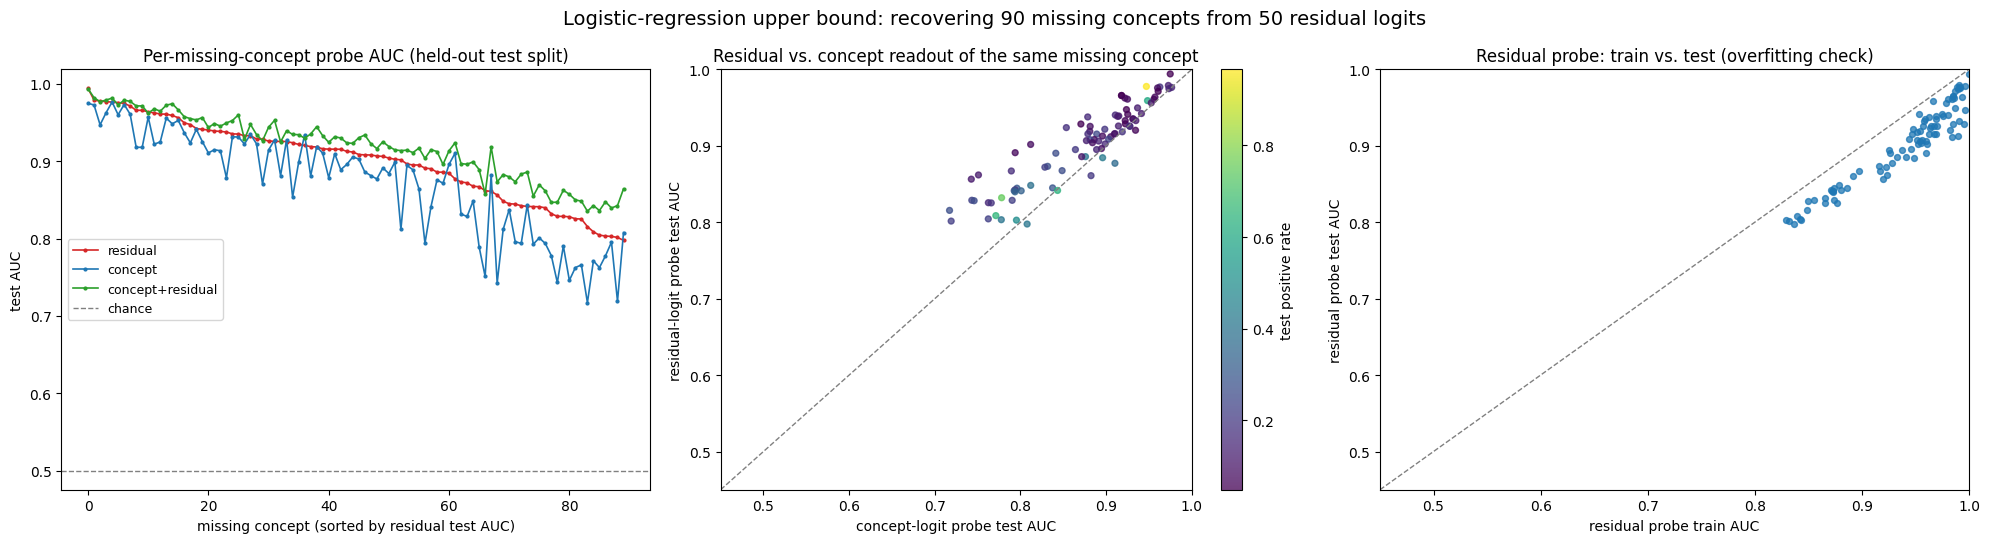

Most residual-readable missing concepts:


,concept_idx_112,concept_name,test_pos_rate,residual_test_auc,concept_test_auc,concept+residual_test_auc,residual_test_bal_acc,residual_minus_concept_auc
0,81,has_shape::duck-like,0.049361,0.993989,0.974760,0.993491,0.957954,0.019229
1,92,has_primary_color::yellow,0.128064,0.978920,0.972587,0.982012,0.943338,0.006333
2,50,has_eye_color::black,0.965827,0.977606,0.946955,0.976903,0.916920,0.030651
3,79,has_size::medium_(9_-_16_in),0.181395,0.976935,0.962687,0.978901,0.941049,0.014248
4,72,has_belly_color::yellow,0.148775,0.976298,0.976433,0.981536,0.944775,-0.000135
5,58,has_forehead_color::white,0.083190,0.975677,0.959986,0.972822,0.928654,0.015691
6,18,has_underparts_color::yellow,0.143597,0.974709,0.973224,0.978792,0.941292,0.001485
7,27,has_back_color::yellow,0.051605,0.971241,0.960698,0.977273,0.924094,0.010543
8,53,has_forehead_color::blue,0.050570,0.965750,0.917931,0.971427,0.916720,0.047819
9,102,has_crown_color::blue,0.050570,0.965750,0.917931,0.971427,0.916720,0.047819


Least residual-readable missing concepts:


,concept_idx_112,concept_name,test_pos_rate,residual_test_auc,concept_test_auc,concept+residual_test_auc,residual_test_bal_acc,residual_minus_concept_auc
75,106,has_crown_color::black,0.330514,0.841094,0.800803,0.869406,0.774635,0.040291
76,57,has_forehead_color::black,0.335347,0.839722,0.793601,0.861604,0.765330,0.046121
77,89,has_belly_pattern::solid,0.749396,0.832010,0.777946,0.846655,0.768021,0.054063
78,5,has_wing_color::grey,0.230756,0.828695,0.743171,0.847039,0.751804,0.085524
79,91,has_primary_color::grey,0.218329,0.828617,0.790288,0.862387,0.745025,0.038329
80,26,has_back_color::grey,0.258198,0.828113,0.745897,0.857146,0.754071,0.082217
81,60,has_under_tail_color::grey,0.151881,0.825526,0.762491,0.849938,0.753207,0.063035
82,33,has_upper_tail_color::grey,0.183293,0.825225,0.765872,0.848250,0.752959,0.059353
83,11,has_upperparts_color::grey,0.269934,0.815447,0.717183,0.835313,0.742231,0.098265
84,22,has_breast_pattern::solid,0.649120,0.808617,0.771223,0.842554,0.733903,0.037393


In [ ]:
# Visual summary of the probes above
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

ranks = np.arange(len(missing_probe_df))
ax = axes[0]
for block_name, color in zip(FEATURE_BLOCKS, ["tab:red", "tab:blue", "tab:green"]):
    ax.plot(ranks, missing_probe_df[f"{block_name}_test_auc"], marker=".", ms=4, lw=1.2,
            color=color, label=block_name)
ax.axhline(0.5, color="grey", ls="--", lw=1, label="chance")
ax.set_xlabel("missing concept (sorted by residual test AUC)")
ax.set_ylabel("test AUC")
ax.set_title("Per-missing-concept probe AUC (held-out test split)")
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(missing_probe_df["concept_test_auc"], missing_probe_df["residual_test_auc"],
           s=18, alpha=0.75, c=missing_probe_df["test_pos_rate"], cmap="viridis")
lims = [0.45, 1.0]
ax.plot(lims, lims, color="grey", ls="--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("concept-logit probe test AUC")
ax.set_ylabel("residual-logit probe test AUC")
ax.set_title("Residual vs. concept readout of the same missing concept")
plt.colorbar(ax.collections[0], ax=ax, label="test positive rate")

ax = axes[2]
ax.scatter(missing_probe_df["residual_train_auc"], missing_probe_df["residual_test_auc"], s=18, alpha=0.75)
ax.plot(lims, lims, color="grey", ls="--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("residual probe train AUC")
ax.set_ylabel("residual probe test AUC")
ax.set_title("Residual probe: train vs. test (overfitting check)")

fig.suptitle(
    f"Logistic-regression upper bound: recovering {len(missing_probe_df)} missing concepts "
    f"from {probe_logits['train'].shape[1] - NUM_CONCEPTS} residual logits",
    fontsize=14,
)
plt.tight_layout()
plt.show()

# Top / bottom missing concepts by residual readability
cols_to_show = ["concept_idx_112", "concept_name", "test_pos_rate",
                "residual_test_auc", "concept_test_auc", "concept+residual_test_auc",
                "residual_test_bal_acc", "residual_minus_concept_auc"]
print("Most residual-readable missing concepts:")
display(missing_probe_df[cols_to_show].head(15))
print("Least residual-readable missing concepts:")
display(missing_probe_df[cols_to_show].tail(15))


## Most activated samples in test set for different residuals

In [ ]:
scbm_res_model = torch.load(os.path.join(EXPERIMENT_PATH, "model.pth"), map_location="cpu")

# What's in there
for k, v in scbm_res_model.items():
    if k.startswith("head"):
        print(k, tuple(v.shape))

# Last linear layer of the head (head.0 for linear head, head.2 for the MLP head)
head_idx = max(int(re.match(r"head\.(\d+)\.weight", k).group(1))
               for k in scbm_res_model if re.match(r"head\.\d+\.weight", k))
W = scbm_res_model[f"head.{head_idx}.weight"]        # [pred_dim, num_concepts + num_residuals]
b = scbm_res_model[f"head.{head_idx}.bias"]          # [pred_dim]
print(f"head.{head_idx}: W {tuple(W.shape)}, b {tuple(b.shape)}")


print(W.shape)

head.0.weight (200, 72)
head.0.bias (200,)
head.0: W (200, 72), b (200,)
torch.Size([200, 72])


## Residual channel analysis

In [ ]:
# Print out test and test concepts and residuals probabilities and binary samples
split = "test"
c_r_probs = torch.load(os.path.join(EXPERIMENT_PATH, split, "concepts_residuals_pred_probs_mean.pt"))
c_r_binarized = (c_r_probs > 0.5).float()  # Binarize the probabilities
y_true = torch.load(os.path.join(EXPERIMENT_PATH, split, "y_true.pt"))
c_r_logits = torch.load(os.path.join(EXPERIMENT_PATH, split, "concepts_residuals_logits_mean.pt"))


print("c_r_probs shape:", c_r_probs.shape)
print("c_r_bin shape:", c_r_binarized.shape)


# Get unique values and their counts for each concept and residual)
unique_probs, counts_probs = torch.unique(c_r_probs, return_counts=True)
unique_bin, counts_bin = torch.unique(c_r_binarized, return_counts=True)


print("Unique binary samples and their counts:")
for u, c in zip(unique_bin, counts_bin):
    print(f"  {u}: {c}")

c_r_probs shape: torch.Size([5794, 72])
c_r_bin shape: torch.Size([5794, 72])
Unique binary samples and their counts:
  0.0: 219002
  1.0: 198166


## Correlation matrix Logits

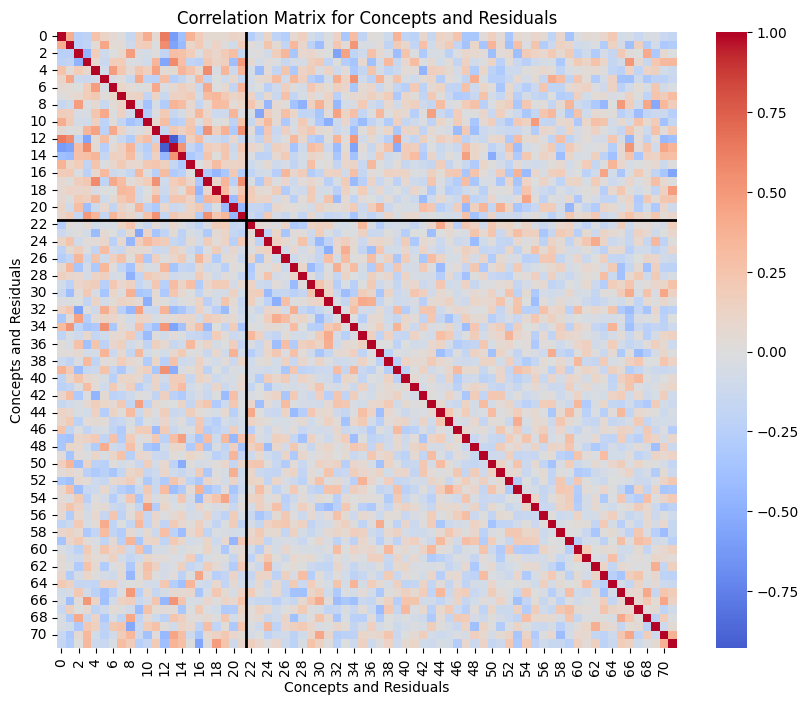

In [ ]:
# Plot correlation matrix for concepts and residuals
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr_matrix = torch.corrcoef(c_r_logits.t())
# Draw lines to split the concepts and residuals in the correlation matrix
num_concepts = 22  # Adjust this based on your actual number of concepts


# Plot correlation matrix
plt.figure(figsize=(10, 8))
plt.axhline(y=num_concepts, color='black', linewidth=2)
plt.axvline(x=num_concepts, color='black', linewidth=2)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Concepts and Residuals')
plt.xlabel('Concepts and Residuals')
plt.ylabel('Concepts and Residuals')
plt.show()

In [ ]:
# Entropy calculation for each concept and residual
def calculate_entropy(probs):
    # Ensure probabilities are in the range (0, 1)
    probs = torch.clamp(probs, min=1e-10, max=1-1e-10)
    return -torch.sum(probs * torch.log(probs) + (1 - probs) * torch.log(1 - probs), dim=0)

# Print entropy for each concept and residual
entropy_values = calculate_entropy(c_r_probs)

# Make this into dataframe with columns: concept/residual, entropy, variation, active_count, inactive_count, ratio_active_inactive
data = []
variation_logits = torch.var(c_r_logits, dim=0)
active_counts = torch.sum(c_r_binarized, dim=0)
inactive_counts = c_r_binarized.shape[0] - active_counts
ratio_active_inactive = active_counts / (inactive_counts + active_counts + 1e-10)

# Also add most correlated residual for each concept and vice versa, and the correlation value
for i in range(c_r_binarized.shape[1]):
    if i < 22:
        data.append({
            "concept/residual": f"Concept {i}",
            "entropy": entropy_values[i].item(),
            "variance logits": variation_logits[i].item(),
            "active_count": active_counts[i].item(),
            "inactive_count": inactive_counts[i].item(),
            "ratio_active_inactive": ratio_active_inactive[i].item(),
            "most correlated residual": f"Residual {torch.argmax(torch.abs(corr_matrix[i, 22:])).item()}",
            "correlation value": corr_matrix[i, 22 + torch.argmax(torch.abs(corr_matrix[i, 22:]))].item()
        })
    else:
        data.append({
            "concept/residual": f"Residual {i-22}",
            "entropy": entropy_values[i].item(),
            "variance logits": variation_logits[i].item(),
            "active_count": active_counts[i].item(),
            "inactive_count": inactive_counts[i].item(),
            "ratio_active_inactive": ratio_active_inactive[i].item(),
            "most correlated concept": f"Concept {torch.argmax(torch.abs(corr_matrix[i, :22])).item()}",
            "correlation value": corr_matrix[i, torch.argmax(torch.abs(corr_matrix[i, :22]))].item()
        })
        
import pandas as pd
df = pd.DataFrame(data)
# dislay all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df)

,concept/residual,entropy,variance logits,active_count,inactive_count,ratio_active_inactive,most correlated residual,correlation value,most correlated concept
0,Concept 0,NaN,35.542027,409.0,5385.0,0.070590,Residual 17,0.360457,NaN
1,Concept 1,NaN,27.645775,318.0,5476.0,0.054884,Residual 12,0.512617,NaN
2,Concept 2,NaN,70.808319,2312.0,3482.0,0.399033,Residual 10,-0.564161,NaN
3,Concept 3,NaN,68.467903,1371.0,4423.0,0.236624,Residual 44,0.498788,NaN
4,Concept 4,138.815674,25.134636,194.0,5600.0,0.033483,Residual 20,-0.463936,NaN
5,Concept 5,NaN,43.662403,1201.0,4593.0,0.207283,Residual 12,0.533737,NaN
6,Concept 6,NaN,22.658222,305.0,5489.0,0.052641,Residual 29,-0.328383,NaN
7,Concept 7,324.833282,23.090763,341.0,5453.0,0.058854,Residual 17,-0.315006,NaN
8,Concept 8,249.016708,41.490540,781.0,5013.0,0.134795,Residual 47,-0.530889,NaN
9,Concept 9,NaN,36.957668,830.0,4964.0,0.143252,Residual 1,-0.550130,NaN


## Concept & residual activation by class

In [ ]:
num_concepts = 22
num_residuals = c_r_probs.shape[1] - num_concepts
dim_names = list(range(c_r_probs.shape[1]))  # 0..21 concepts, 22..71 residuals
class_names = list(range(200))

print(f"{num_concepts} concepts, {num_residuals} residuals, {len(class_names)} classes")

22 concepts, 50 residuals, 200 classes


In [ ]:
# Mean predicted activation probability of each concept/residual, per ground-truth class.
# the global y_true with the test split's version as a side effect.
y_true = torch.load(os.path.join(EXPERIMENT_PATH, split, "y_true.pt"))

df_dims = pd.DataFrame(c_r_probs.numpy(), columns=dim_names)
df_dims["class"] = y_true.numpy()
class_means = df_dims.groupby("class").mean()
class_means.index = [class_names[i] for i in class_means.index]

print("class_means shape:", class_means.shape)
class_means.head()

class_means shape: (200, 72)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,0.001542,0.897848,0.003530,0.001359,0.000418,0.158754,0.001295,0.003846,0.000561,0.096770,0.147814,0.001349,0.974897,0.004141,0.007628,0.026288,0.965340,0.000203,0.001107,0.000498,0.227324,0.003255,0.959105,0.210070,0.899247,0.248112,0.941857,0.992105,0.816737,0.648055,0.146208,0.899289,0.955335,0.284721,0.960536,0.899481,0.867615,0.221529,0.150784,0.849834,0.840433,0.078445,0.988231,0.757074,0.954559,0.972448,0.687445,0.086175,0.535315,0.046081,0.980768,0.956091,0.088745,0.994297,0.117030,0.889408,0.547695,0.189871,0.292717,0.949664,0.252795,0.101676,0.811903,0.101828,0.870632,0.723804,0.189752,0.956059,0.267541,0.943977,0.135035,0.054195
1,0.002285,0.754337,0.041493,0.024123,0.001617,0.159668,0.044104,0.000444,0.006350,0.021406,0.708353,0.030893,0.928990,0.067610,0.043268,0.006859,0.401966,0.014508,0.044271,0.007501,0.120192,0.305638,0.660868,0.442038,0.878627,0.482781,0.308340,0.975269,0.440883,0.634909,0.247838,0.682432,0.947675,0.810360,0.914380,0.630672,0.692487,0.424219,0.361358,0.929832,0.537550,0.693204,0.985216,0.529642,0.795914,0.898908,0.331080,0.648543,0.554938,0.021228,0.974308,0.842680,0.133646,0.949105,0.798904,0.906516,0.222418,0.146257,0.892745,0.952146,0.432858,0.270716,0.638576,0.061273,0.377546,0.891949,0.176998,0.917662,0.247524,0.897895,0.163683,0.116754
2,0.005464,0.762564,0.078527,0.006065,0.000571,0.032998,0.002925,0.003715,0.003329,0.029200,0.144861,0.001235,0.936594,0.050744,0.020025,0.011483,0.898012,0.000432,0.001966,0.000547,0.765714,0.001436,0.899614,0.113897,0.794186,0.306847,0.830320,0.966734,0.829881,0.685641,0.750779,0.876611,0.798164,0.289840,0.939285,0.882803,0.938484,0.122934,0.128608,0.839553,0.865646,0.237344,0.995710,0.439660,0.844949,0.985331,0.824354,0.035481,0.780048,0.041806,0.952913,0.996858,0.086900,0.958597,0.066804,0.945436,0.726840,0.126545,0.248219,0.871860,0.115578,0.202825,0.375715,0.141128,0.872082,0.874596,0.746121,0.981644,0.214087,0.941317,0.532396,0.005210
3,0.005107,0.006658,0.172557,0.068177,0.003620,0.857111,0.003936,0.008956,0.001905,0.840256,0.014349,0.000527,0.463772,0.545314,0.237773,0.003653,0.906634,0.000460,0.002720,0.005948,0.925581,0.000296,0.185824,0.212970,0.461201,0.906623,0.895180,0.781796,0.662776,0.606657,0.090645,0.771623,0.963460,0.951182,0.930535,0.326533,0.396610,0.966142,0.808904,0.686081,0.551242,0.256990,0.729640,0.945926,0.274690,0.242032,0.921264,0.336727,0.974083,0.945147,0.108787,0.875666,0.958127,0.719133,0.157113,0.489282,0.554539,0.933930,0.856084,0.079672,0.945478,0.478313,0.117927,0.607634,0.716459,0.049648,0.188683,0.175423,0.090204,0.227216,0.593612,0.610744
4,0.008204,0.108635,0.004612,0.022885,0.001793,0.101954,0.001059,0.538071,0.002748,0.855149,0.128693,0.003327,0.307810,0.662199,0.023237,0.614404,0.991993,0.000520,0.004545,0.010882,0.076209,0.000998,0.965742,0.136723,0.315936,0.048022,0.994458,0.763772,0.029026,0.763919,0.046825,0.939967,0.771955,0.123210,0.993852,0.783868,0.928175,0.880485,0.564324,0.495831,0.526864,0.101824,0.354822,0.613977,0.983108,0.899652,0.816005,0.322682,0.685681,0.210630,0.935879,0.963902,0.139999,0.996919,0.462218,0.832421,0.184244,0.949460,0.611083,0.918291,0.966200,0.647631,0.795083,0.804184,0.919699,0.101723,0.591777,0.816728,0.543937,0.956850,0.030952,0.051403


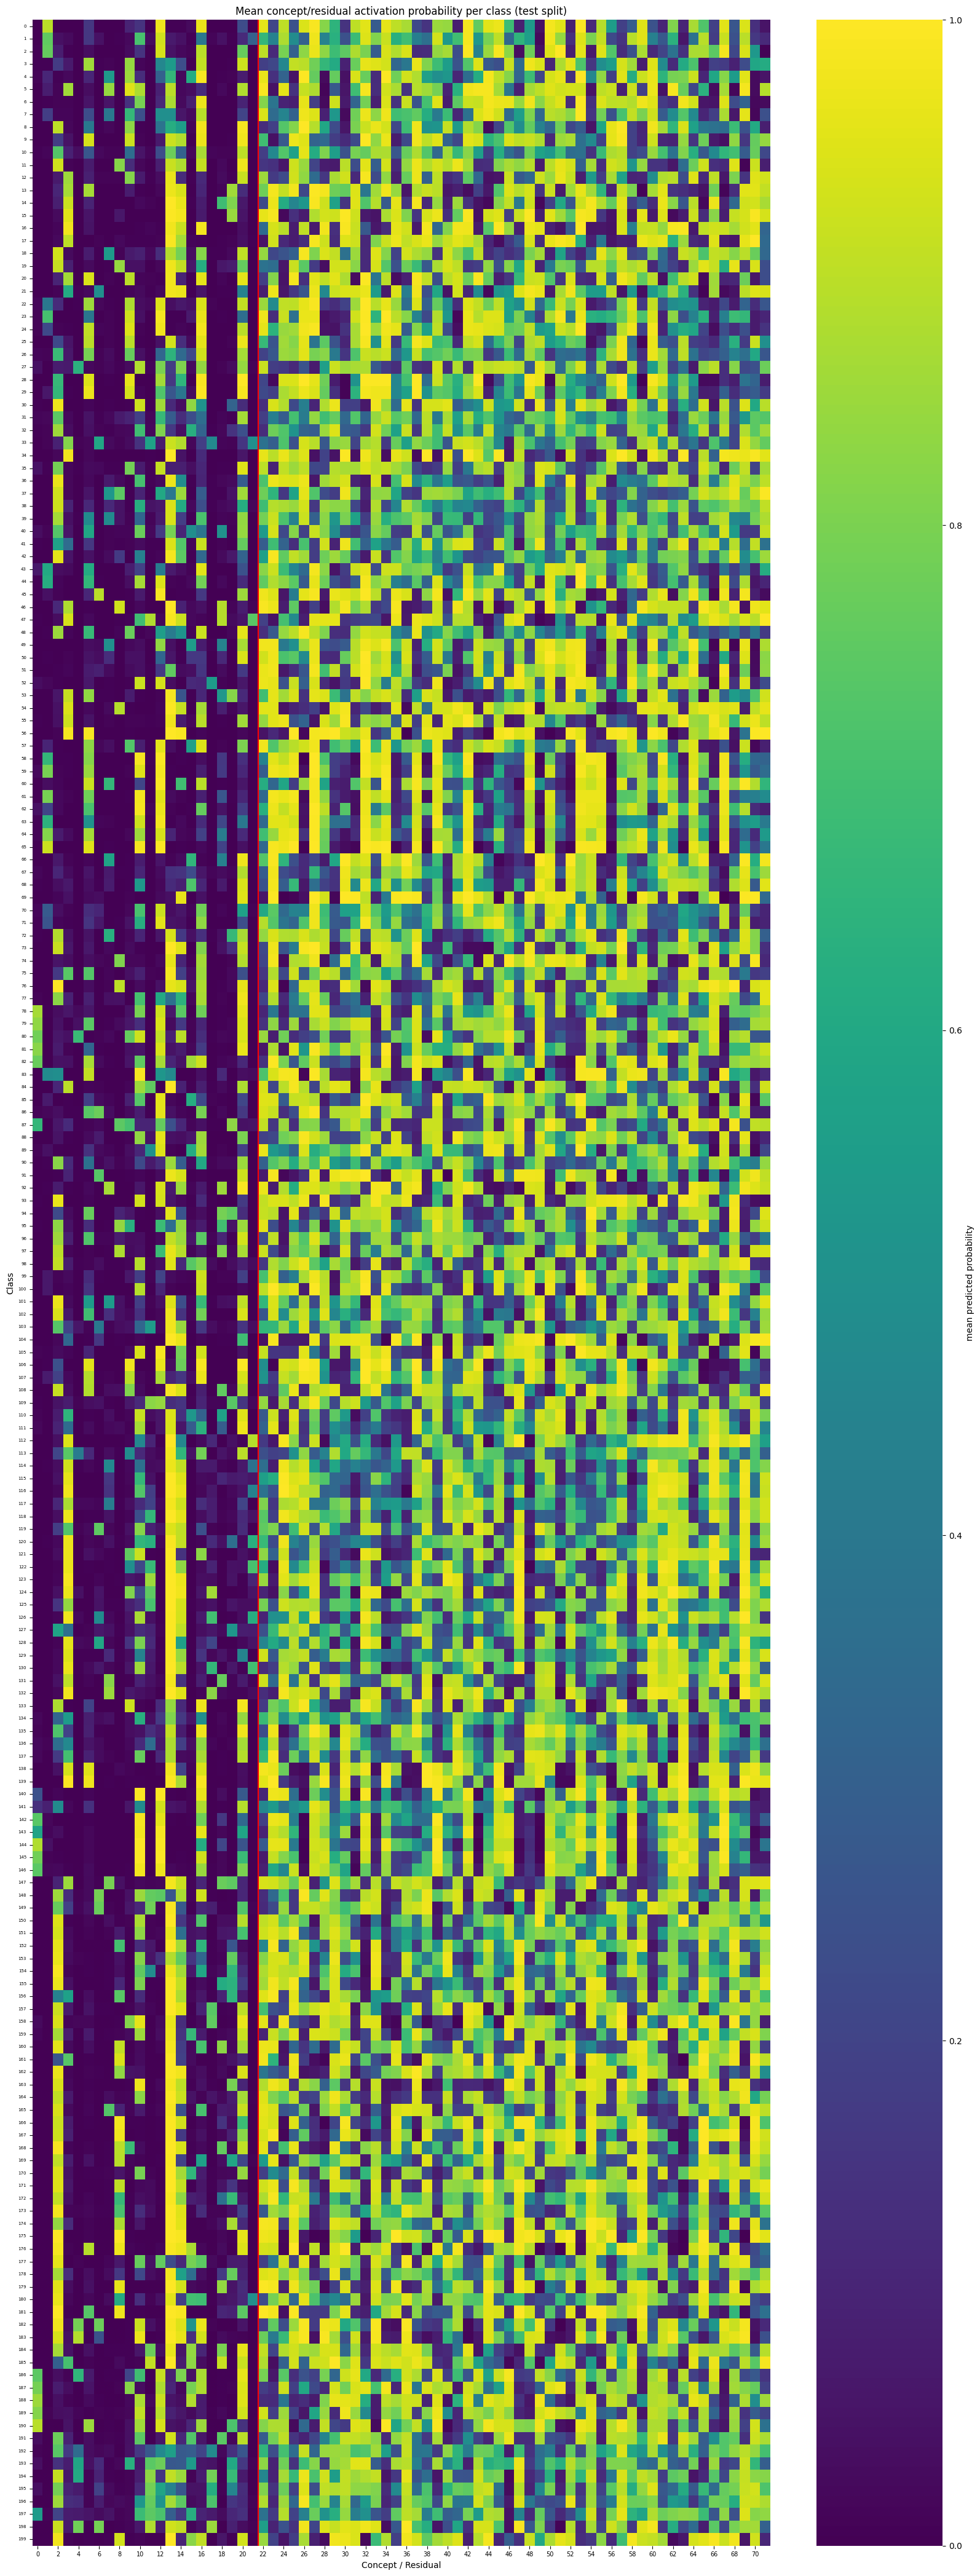

In [ ]:
# Full heatmap: all 200 classes x all 22 concepts + 50 residuals
plt.figure(figsize=(16, 42))
sns.heatmap(
    class_means,
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "mean predicted probability"},
)
plt.axvline(num_concepts, color="red", linewidth=1.5)  # concepts | residuals boundary
plt.title(f"Mean concept/residual activation probability per class ({split} split)")
plt.xlabel("Concept / Residual")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

In [ ]:
# Top-k most active concepts/residuals per class (quick lookup instead of scanning the full heatmap)
def top_active_dims(class_means, k=5):
    rows = []
    for cls_name, row in class_means.iterrows():
        top = row.sort_values(ascending=False).head(k)
        rows.append({
            "class": cls_name,
            **{f"top_{i+1}": f"{name} ({val:.2f})" for i, (name, val) in enumerate(top.items())},
        })
    return pd.DataFrame(rows).set_index("class")

top_dims_df = top_active_dims(class_means, k=5)
pd.set_option("display.max_rows", None)
# display(top_dims_df)

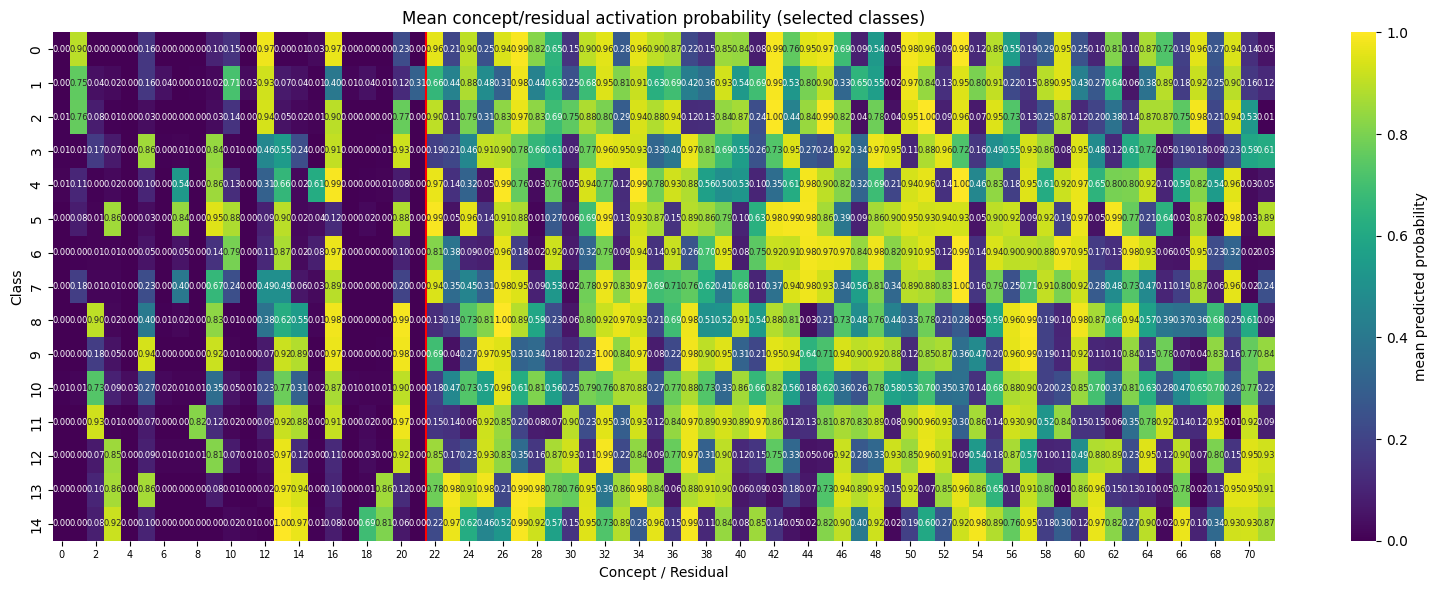

In [ ]:
# Zoomed-in heatmap for a chosen subset of classes (edit CLASSES_TO_SHOW)
CLASSES_TO_SHOW = class_names[:15]  # e.g. class_names[:15], or pick specific species by name

plt.figure(figsize=(16, max(4, 0.4 * len(CLASSES_TO_SHOW))))
sns.heatmap(
    class_means.loc[CLASSES_TO_SHOW],
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "mean predicted probability"},
)
plt.axvline(num_concepts, color="red", linewidth=1.5)
plt.title("Mean concept/residual activation probability (selected classes)")
plt.xlabel("Concept / Residual")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
full_dataset_path = os.path.join("datasets", "CUB", "class_attr_data_10")



Top 5 missing concepts and their indices:
  has_breast_pattern::striped: 23
  has_size::very_small_(3_-_5_in): 80
  has_shape::duck-like: 81
  has_primary_color::yellow: 92
  has_wing_pattern::striped: 110


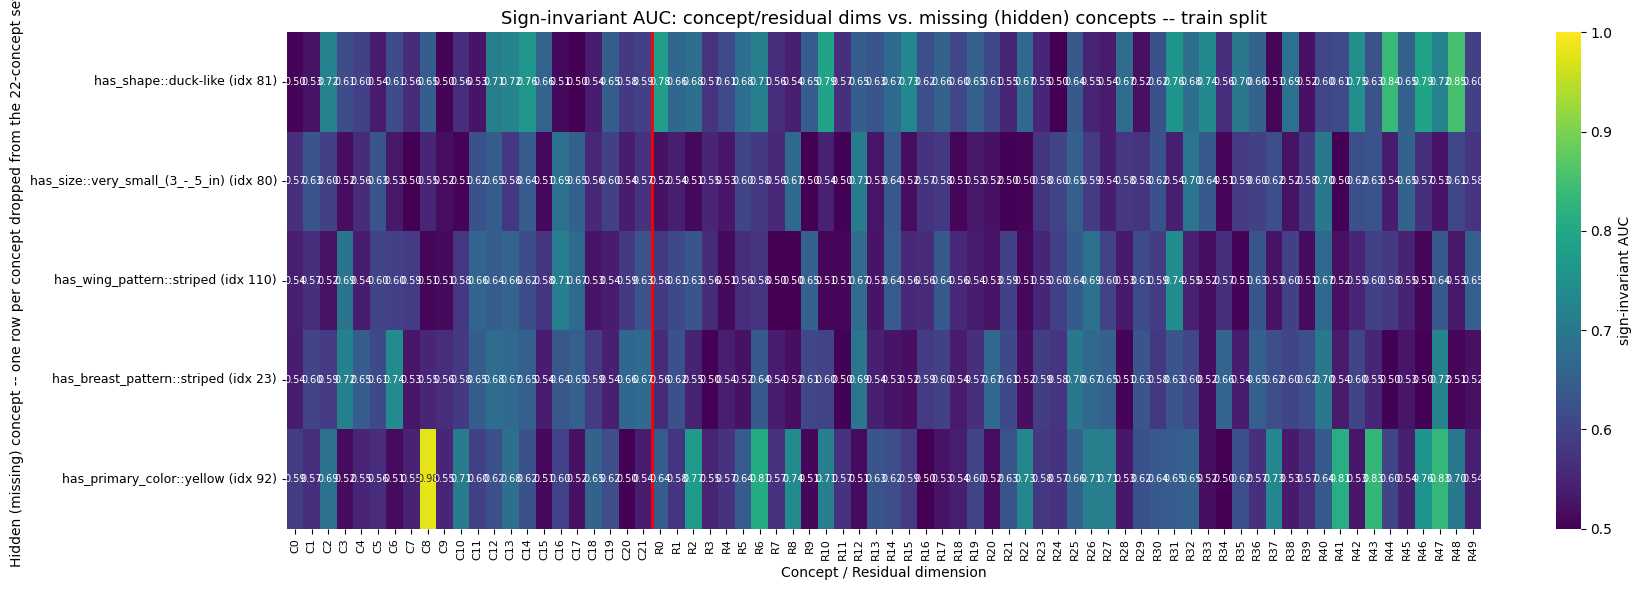

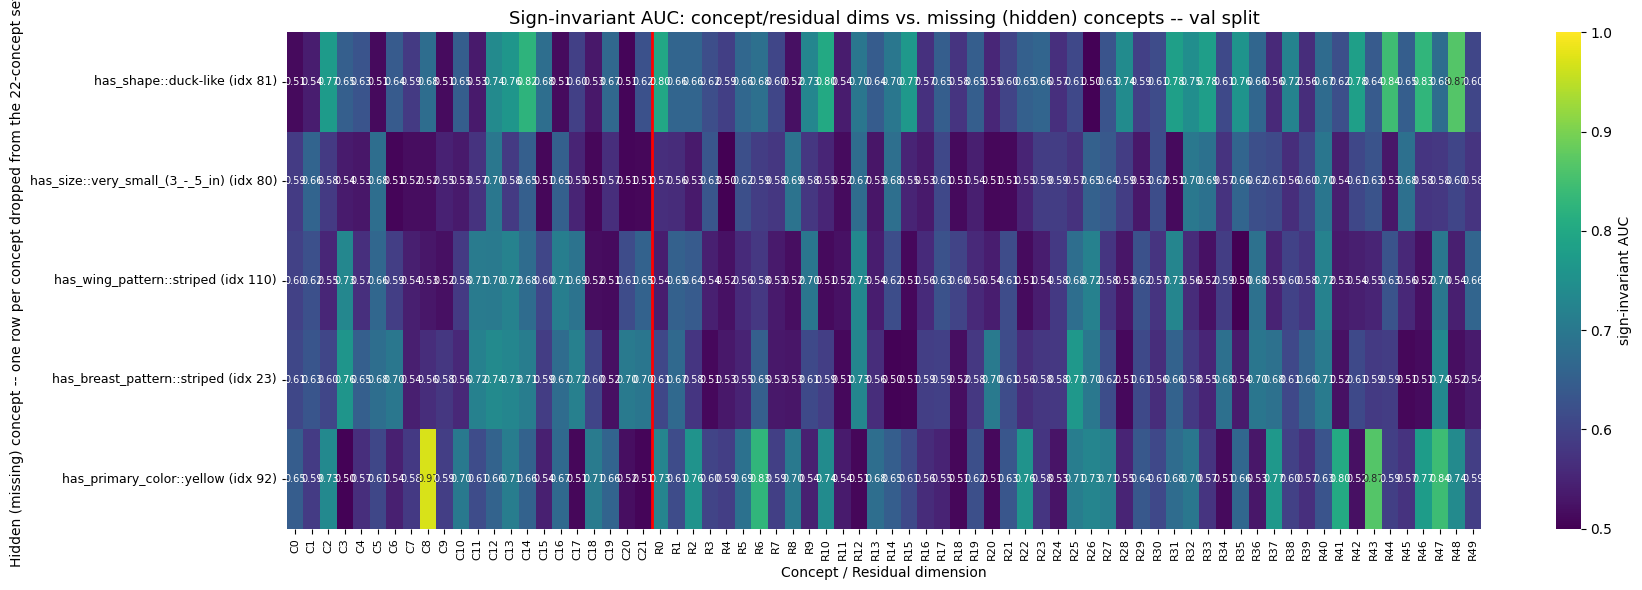

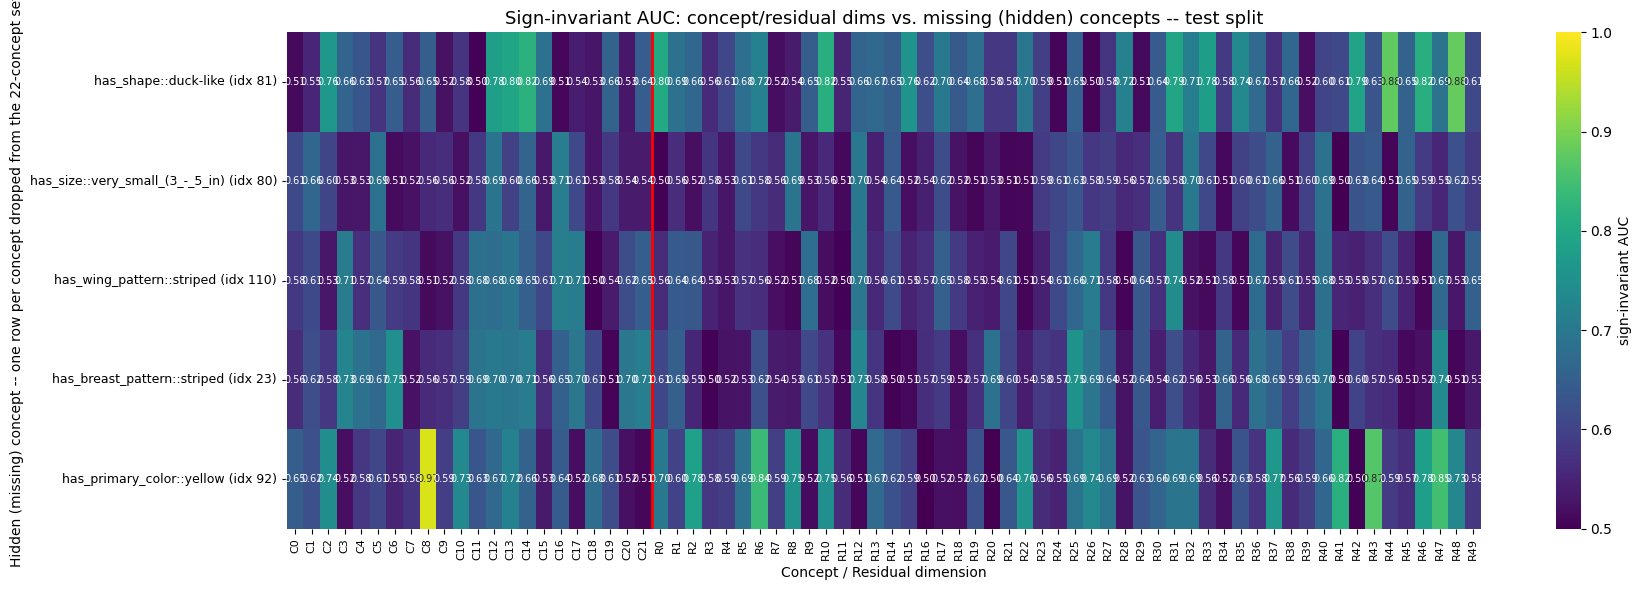

In [ ]:
top5_missing_concepts = [
    "has_shape::duck-like",
    "has_size::very_small_(3_-_5_in)",
    "has_wing_pattern::striped",
    "has_breast_pattern::striped",
    "has_primary_color::yellow",
]

idx_top5_missing_concepts = {}


for key, val in sample_112_concepts_map.items():

    if val in top5_missing_concepts:
        idx_top5_missing_concepts[val] = key

print("Top 5 missing concepts and their indices:")
for concept, idx in idx_top5_missing_concepts.items():
    print(f"  {concept}: {idx}")



# Plot AUC Heat map of top 5 missing concepts and residuals for each split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Full (112-concept) dataset: same samples/order as the 22-concept "incomplete" pkls
# (verified ids match exactly), but attribute_label here is indexed 0-111, i.e. directly
# by the same index as idx_top5_missing_concepts -- no need to go through the original
# 312-attribute space.
full_dataset_path = os.path.join("datasets", "CUB", "class_attr_data_10")

heatmap_num_concepts = 22
heatmap_splits = ["train", "val", "test"]

# y-axis: one row per missing (hidden) concept -- row order matches top5_missing_concepts.
# Label each row with the concept name plus its index in the 112-concept space, so it's
# unambiguous which row is which hidden concept.
y_axis_labels = [f"{concept} (idx {idx_top5_missing_concepts[concept]})" for concept in top5_missing_concepts]

for split in heatmap_splits:
    full_split_data = pd.read_pickle(os.path.join(full_dataset_path, f"{split}.pkl"))

    c_r_probs_split = torch.load(
        os.path.join(EXPERIMENT_PATH, split, "concepts_residuals_pred_probs_mean.pt")
    ).numpy()
    num_dims = c_r_probs_split.shape[1]
    dim_labels = [f"C{i}" if i < heatmap_num_concepts else f"R{i - heatmap_num_concepts}" for i in range(num_dims)]

    auc_matrix = np.full((len(top5_missing_concepts), num_dims), np.nan)
    for row, concept in enumerate(top5_missing_concepts):
        concept_idx_112 = idx_top5_missing_concepts[concept]
        c_true_missing = np.array([sample["attribute_label"][concept_idx_112] for sample in full_split_data])

        if len(np.unique(c_true_missing)) < 2:
            continue  # concept has no variation in this split, AUC undefined

        for col in range(num_dims):
            raw_auc = roc_auc_score(c_true_missing, c_r_probs_split[:, col])
            auc_matrix[row, col] = max(raw_auc, 1 - raw_auc)  # sign-invariant AUC

    fig, ax = plt.subplots(figsize=(18, 6))
    sns.heatmap(
        auc_matrix,
        ax=ax,
        cmap="viridis",
        vmin=0.5,
        vmax=1.0,
        xticklabels=dim_labels,
        yticklabels=y_axis_labels,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 7},
        cbar_kws={"label": "sign-invariant AUC"},
    )
    ax.axvline(heatmap_num_concepts, color="red", linewidth=2)
    ax.set_title(f"Sign-invariant AUC: concept/residual dims vs. missing (hidden) concepts -- {split} split", fontsize=13)
    ax.set_xlabel("Concept / Residual dimension")
    ax.set_ylabel("Hidden (missing) concept -- one row per concept dropped from the 22-concept set")
    ax.tick_params(axis="x", labelrotation=90, labelsize=8)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9)
    plt.tight_layout()
    plt.show()

{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

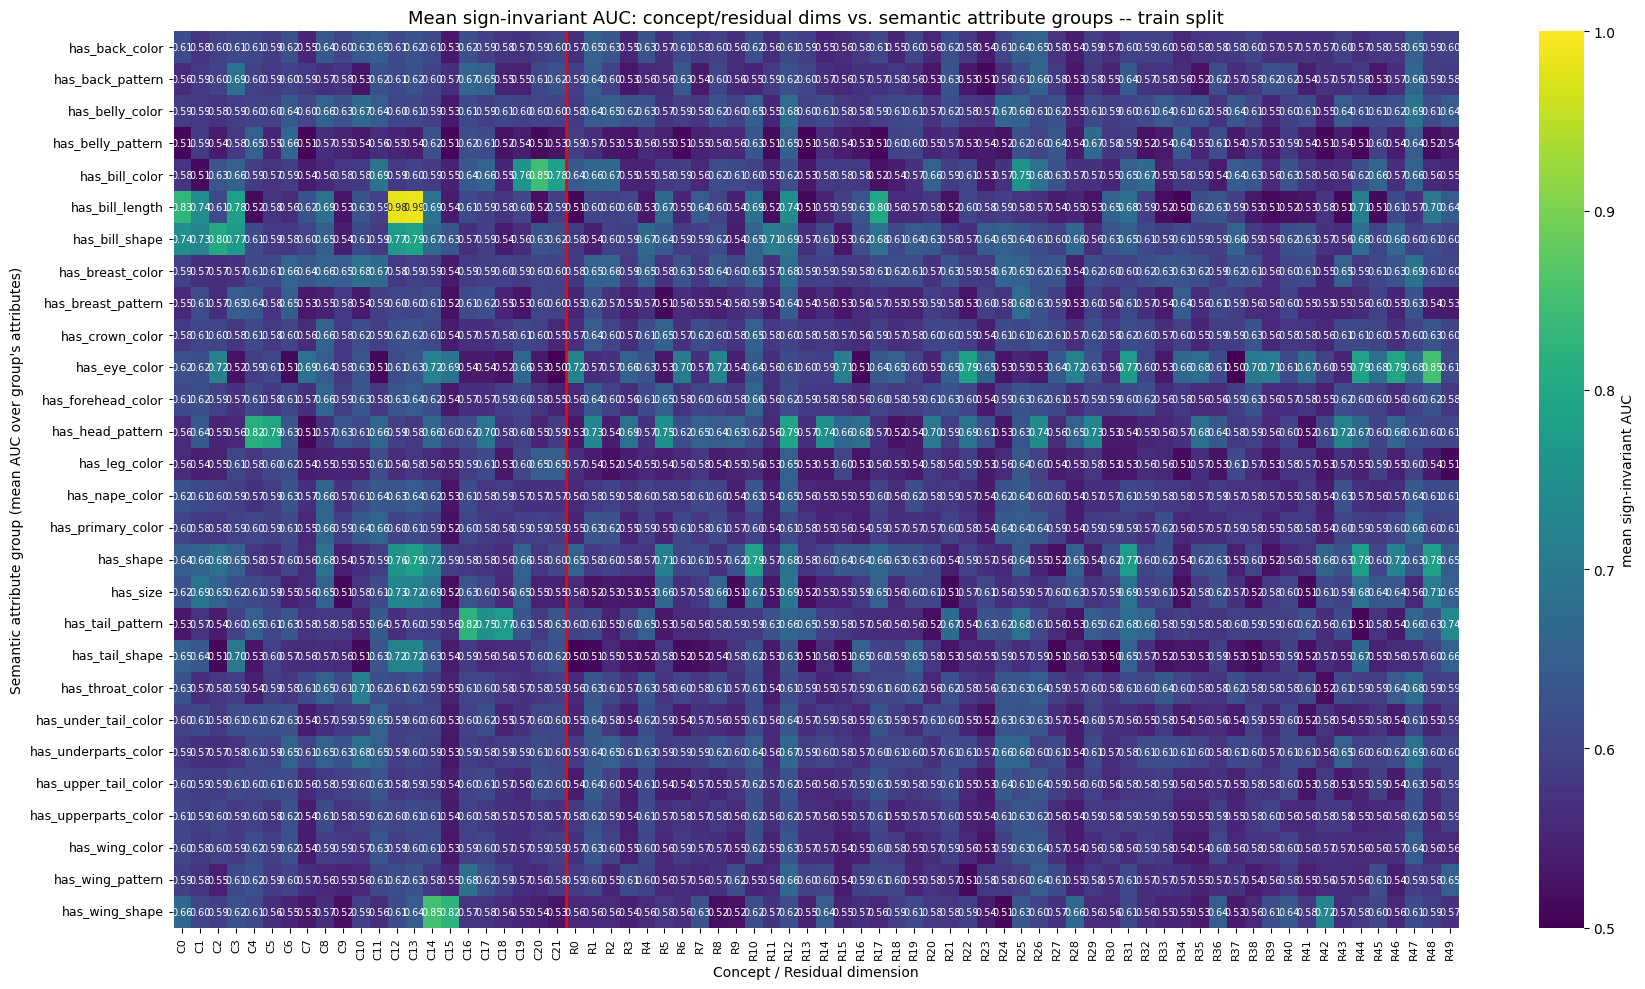

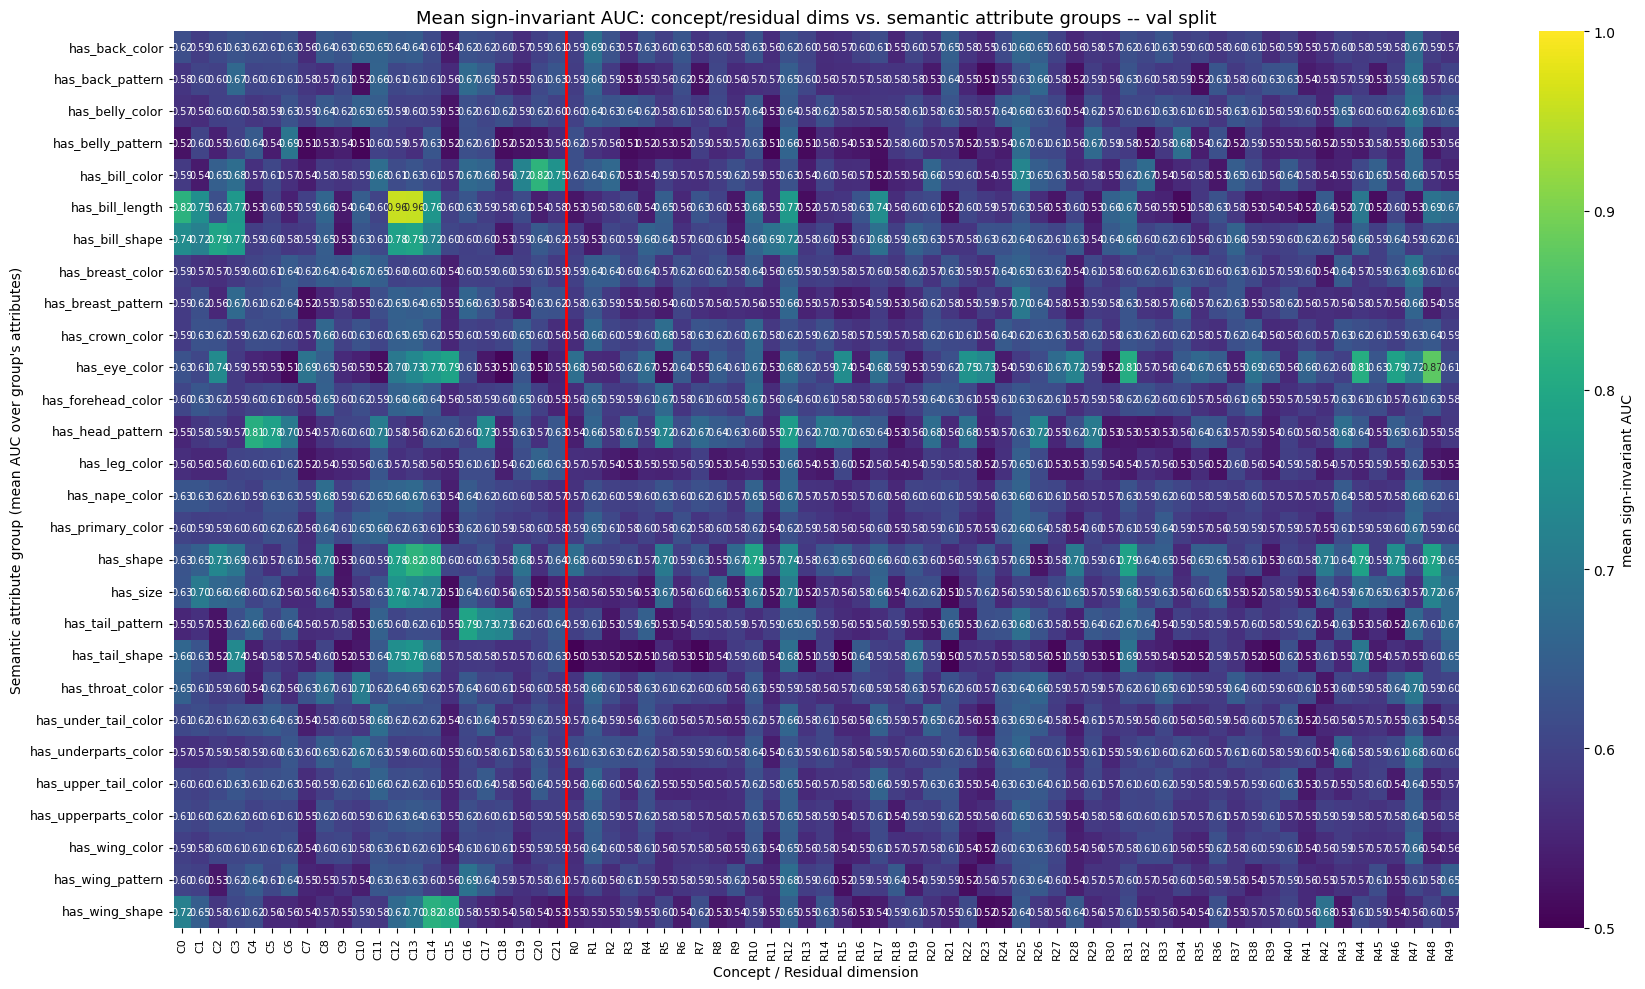

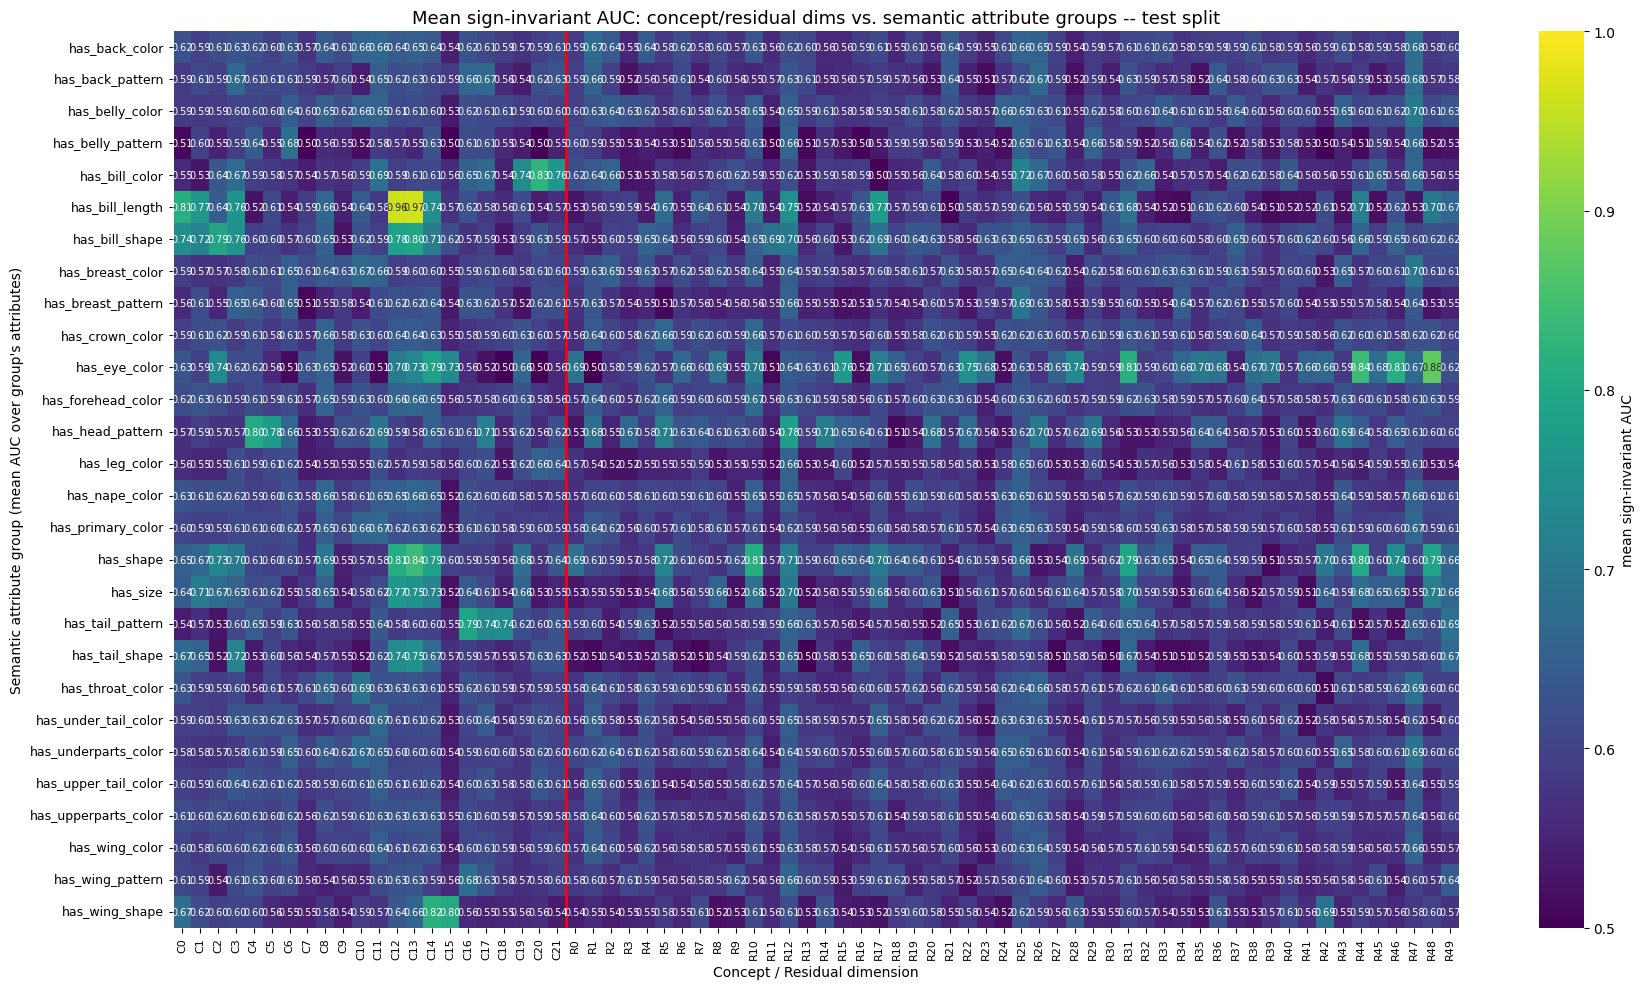

In [ ]:
from collections import defaultdict


print(sample_112_concepts_map)
semantic_groups = list(set([name.split("::")[0] for name in sample_112_concepts_map.values()]))
print(semantic_groups)

# Plot AUC of semantic groups and residuals for each split

# Map each semantic group (e.g. "has_bill_shape") to its constituent attribute
# indices in the 112-concept space.
semantic_group_to_indices = defaultdict(list)
for idx, name in sample_112_concepts_map.items():
    group = name.split("::")[0]
    semantic_group_to_indices[group].append(idx)

semantic_groups = sorted(semantic_group_to_indices.keys())
print(f"{len(semantic_groups)} semantic groups")
for group in semantic_groups:
    print(f"  {group}: {semantic_group_to_indices[group]}")

heatmap_num_concepts = 22
heatmap_splits = ["train", "val", "test"]

for split in heatmap_splits:
    full_split_data = pd.read_pickle(os.path.join(full_dataset_path, f"{split}.pkl"))
    c_true_112 = np.array([sample["attribute_label"] for sample in full_split_data])

    c_r_mu_split = torch.load(
        os.path.join(EXPERIMENT_PATH, split, "c_res_mu.pt")
    ).numpy()
    num_dims = c_r_mu_split.shape[1]
    dim_labels = [f"C{i}" if i < heatmap_num_concepts else f"R{i - heatmap_num_concepts}" for i in range(num_dims)]

    # For each (semantic group, dim) pair, take the mean sign-invariant AUC over the
    # group's constituent (112-space) attributes -- how well the dim tracks the group
    # overall, rather than any single attribute value within it.
    auc_matrix = np.full((len(semantic_groups), num_dims), np.nan)
    for row, group in enumerate(semantic_groups):
        attr_idxs = semantic_group_to_indices[group]
        for col in range(num_dims):
            aucs = []
            for attr_idx in attr_idxs:
                c_true_attr = c_true_112[:, attr_idx]
                if len(np.unique(c_true_attr)) < 2:
                    continue  # attribute has no variation in this split, AUC undefined
                raw_auc = roc_auc_score(c_true_attr, c_r_mu_split[:, col])
                aucs.append(max(raw_auc, 1 - raw_auc))  # sign-invariant AUC
            if aucs:
                auc_matrix[row, col] = np.mean(aucs)

    fig, ax = plt.subplots(figsize=(18, 10))
    sns.heatmap(
        auc_matrix,
        ax=ax,
        cmap="viridis",
        vmin=0.5,
        vmax=1.0,
        xticklabels=dim_labels,
        yticklabels=semantic_groups,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 7},
        cbar_kws={"label": "mean sign-invariant AUC"},
    )
    ax.axvline(heatmap_num_concepts, color="red", linewidth=2)
    ax.set_title(f"Mean sign-invariant AUC: concept/residual dims vs. semantic attribute groups -- {split} split", fontsize=13)
    ax.set_xlabel("Concept / Residual dimension")
    ax.set_ylabel("Semantic attribute group (mean AUC over group's attributes)")
    ax.tick_params(axis="x", labelrotation=90, labelsize=8)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9)
    plt.tight_layout()
    plt.show()


## Check that the CUB dataset is correct

In [ ]:
# My code
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]




def get_attribute_parts_to_indices():
    """
    Maps attribute idx to attribute parts (e.g. bill, wing, etc.)
    """
    
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    

    path_attrubute_file = os.path.join("datasets", "CUB/CUB_200_2011/attributes.txt")



    with open(path_attrubute_file, "r") as f:
        lines = f.readlines()
        semantic_groups = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            semantic_group = attr_name.split("::")[0]
            if semantic_group not in semantic_groups:
                semantic_groups[semantic_group] = []
            semantic_groups[semantic_group].append(new_idx)

        return semantic_groups
    
    
print("Attribute parts to indices mapping:")
attribute_parts_to_indices = get_attribute_parts_to_indices()
for part, indices in attribute_parts_to_indices.items():
    print(f"{part}: {indices}")
    

Attribute parts to indices mapping:
has_bill_shape: [0, 1, 2, 3]
has_wing_color: [4, 5, 6, 7, 8, 9]
has_upperparts_color: [10, 11, 12, 13, 14, 15]
has_underparts_color: [16, 17, 18, 19, 20, 21]
has_breast_pattern: [22, 23, 24]
has_back_color: [25, 26, 27, 28, 29, 30]
has_tail_shape: [31]
has_upper_tail_color: [32, 33, 34, 35, 36]
has_head_pattern: [37, 38]
has_breast_color: [39, 40, 41, 42, 43, 44]
has_throat_color: [45, 46, 47, 48, 49]
has_eye_color: [50]
has_bill_length: [51, 52]
has_forehead_color: [53, 54, 55, 56, 57, 58]
has_under_tail_color: [59, 60, 61, 62, 63]
has_nape_color: [64, 65, 66, 67, 68, 69]
has_belly_color: [70, 71, 72, 73, 74, 75]
has_wing_shape: [76, 77]
has_size: [78, 79, 80]
has_shape: [81, 82]
has_back_pattern: [83, 84, 85]
has_tail_pattern: [86, 87, 88]
has_belly_pattern: [89]
has_primary_color: [90, 91, 92, 93, 94, 95]
has_leg_color: [96, 97, 98]
has_bill_color: [99, 100, 101]
has_crown_color: [102, 103, 104, 105, 106, 107]
has_wing_pattern: [108, 109, 110, 111

In [ ]:
# Mateo code

from collections import defaultdict


SELECTED_CONCEPTS = [
    1,
    4,
    6,
    7,
    10,
    14,
    15,
    20,
    21,
    23,
    25,
    29,
    30,
    35,
    36,
    38,
    40,
    44,
    45,
    50,
    51,
    53,
    54,
    56,
    57,
    59,
    63,
    64,
    69,
    70,
    72,
    75,
    80,
    84,
    90,
    91,
    93,
    99,
    101,
    106,
    110,
    111,
    116,
    117,
    119,
    125,
    126,
    131,
    132,
    134,
    145,
    149,
    151,
    152,
    153,
    157,
    158,
    163,
    164,
    168,
    172,
    178,
    179,
    181,
    183,
    187,
    188,
    193,
    194,
    196,
    198,
    202,
    203,
    208,
    209,
    211,
    212,
    213,
    218,
    220,
    221,
    225,
    235,
    236,
    238,
    239,
    240,
    242,
    243,
    244,
    249,
    253,
    254,
    259,
    260,
    262,
    268,
    274,
    277,
    283,
    289,
    292,
    293,
    294,
    298,
    299,
    304,
    305,
    308,
    309,
    310,
    311,
]

# Names of all CUB attributes
CONCEPT_SEMANTICS = [
    "has_bill_shape::curved_(up_or_down)",
    "has_bill_shape::dagger",
    "has_bill_shape::hooked",
    "has_bill_shape::needle",
    "has_bill_shape::hooked_seabird",
    "has_bill_shape::spatulate",
    "has_bill_shape::all-purpose",
    "has_bill_shape::cone",
    "has_bill_shape::specialized",
    "has_wing_color::blue",
    "has_wing_color::brown",
    "has_wing_color::iridescent",
    "has_wing_color::purple",
    "has_wing_color::rufous",
    "has_wing_color::grey",
    "has_wing_color::yellow",
    "has_wing_color::olive",
    "has_wing_color::green",
    "has_wing_color::pink",
    "has_wing_color::orange",
    "has_wing_color::black",
    "has_wing_color::white",
    "has_wing_color::red",
    "has_wing_color::buff",
    "has_upperparts_color::blue",
    "has_upperparts_color::brown",
    "has_upperparts_color::iridescent",
    "has_upperparts_color::purple",
    "has_upperparts_color::rufous",
    "has_upperparts_color::grey",
    "has_upperparts_color::yellow",
    "has_upperparts_color::olive",
    "has_upperparts_color::green",
    "has_upperparts_color::pink",
    "has_upperparts_color::orange",
    "has_upperparts_color::black",
    "has_upperparts_color::white",
    "has_upperparts_color::red",
    "has_upperparts_color::buff",
    "has_underparts_color::blue",
    "has_underparts_color::brown",
    "has_underparts_color::iridescent",
    "has_underparts_color::purple",
    "has_underparts_color::rufous",
    "has_underparts_color::grey",
    "has_underparts_color::yellow",
    "has_underparts_color::olive",
    "has_underparts_color::green",
    "has_underparts_color::pink",
    "has_underparts_color::orange",
    "has_underparts_color::black",
    "has_underparts_color::white",
    "has_underparts_color::red",
    "has_underparts_color::buff",
    "has_breast_pattern::solid",
    "has_breast_pattern::spotted",
    "has_breast_pattern::striped",
    "has_breast_pattern::multi-colored",
    "has_back_color::blue",
    "has_back_color::brown",
    "has_back_color::iridescent",
    "has_back_color::purple",
    "has_back_color::rufous",
    "has_back_color::grey",
    "has_back_color::yellow",
    "has_back_color::olive",
    "has_back_color::green",
    "has_back_color::pink",
    "has_back_color::orange",
    "has_back_color::black",
    "has_back_color::white",
    "has_back_color::red",
    "has_back_color::buff",
    "has_tail_shape::forked_tail",
    "has_tail_shape::rounded_tail",
    "has_tail_shape::notched_tail",
    "has_tail_shape::fan-shaped_tail",
    "has_tail_shape::pointed_tail",
    "has_tail_shape::squared_tail",
    "has_upper_tail_color::blue",
    "has_upper_tail_color::brown",
    "has_upper_tail_color::iridescent",
    "has_upper_tail_color::purple",
    "has_upper_tail_color::rufous",
    "has_upper_tail_color::grey",
    "has_upper_tail_color::yellow",
    "has_upper_tail_color::olive",
    "has_upper_tail_color::green",
    "has_upper_tail_color::pink",
    "has_upper_tail_color::orange",
    "has_upper_tail_color::black",
    "has_upper_tail_color::white",
    "has_upper_tail_color::red",
    "has_upper_tail_color::buff",
    "has_head_pattern::spotted",
    "has_head_pattern::malar",
    "has_head_pattern::crested",
    "has_head_pattern::masked",
    "has_head_pattern::unique_pattern",
    "has_head_pattern::eyebrow",
    "has_head_pattern::eyering",
    "has_head_pattern::plain",
    "has_head_pattern::eyeline",
    "has_head_pattern::striped",
    "has_head_pattern::capped",
    "has_breast_color::blue",
    "has_breast_color::brown",
    "has_breast_color::iridescent",
    "has_breast_color::purple",
    "has_breast_color::rufous",
    "has_breast_color::grey",
    "has_breast_color::yellow",
    "has_breast_color::olive",
    "has_breast_color::green",
    "has_breast_color::pink",
    "has_breast_color::orange",
    "has_breast_color::black",
    "has_breast_color::white",
    "has_breast_color::red",
    "has_breast_color::buff",
    "has_throat_color::blue",
    "has_throat_color::brown",
    "has_throat_color::iridescent",
    "has_throat_color::purple",
    "has_throat_color::rufous",
    "has_throat_color::grey",
    "has_throat_color::yellow",
    "has_throat_color::olive",
    "has_throat_color::green",
    "has_throat_color::pink",
    "has_throat_color::orange",
    "has_throat_color::black",
    "has_throat_color::white",
    "has_throat_color::red",
    "has_throat_color::buff",
    "has_eye_color::blue",
    "has_eye_color::brown",
    "has_eye_color::purple",
    "has_eye_color::rufous",
    "has_eye_color::grey",
    "has_eye_color::yellow",
    "has_eye_color::olive",
    "has_eye_color::green",
    "has_eye_color::pink",
    "has_eye_color::orange",
    "has_eye_color::black",
    "has_eye_color::white",
    "has_eye_color::red",
    "has_eye_color::buff",
    "has_bill_length::about_the_same_as_head",
    "has_bill_length::longer_than_head",
    "has_bill_length::shorter_than_head",
    "has_forehead_color::blue",
    "has_forehead_color::brown",
    "has_forehead_color::iridescent",
    "has_forehead_color::purple",
    "has_forehead_color::rufous",
    "has_forehead_color::grey",
    "has_forehead_color::yellow",
    "has_forehead_color::olive",
    "has_forehead_color::green",
    "has_forehead_color::pink",
    "has_forehead_color::orange",
    "has_forehead_color::black",
    "has_forehead_color::white",
    "has_forehead_color::red",
    "has_forehead_color::buff",
    "has_under_tail_color::blue",
    "has_under_tail_color::brown",
    "has_under_tail_color::iridescent",
    "has_under_tail_color::purple",
    "has_under_tail_color::rufous",
    "has_under_tail_color::grey",
    "has_under_tail_color::yellow",
    "has_under_tail_color::olive",
    "has_under_tail_color::green",
    "has_under_tail_color::pink",
    "has_under_tail_color::orange",
    "has_under_tail_color::black",
    "has_under_tail_color::white",
    "has_under_tail_color::red",
    "has_under_tail_color::buff",
    "has_nape_color::blue",
    "has_nape_color::brown",
    "has_nape_color::iridescent",
    "has_nape_color::purple",
    "has_nape_color::rufous",
    "has_nape_color::grey",
    "has_nape_color::yellow",
    "has_nape_color::olive",
    "has_nape_color::green",
    "has_nape_color::pink",
    "has_nape_color::orange",
    "has_nape_color::black",
    "has_nape_color::white",
    "has_nape_color::red",
    "has_nape_color::buff",
    "has_belly_color::blue",
    "has_belly_color::brown",
    "has_belly_color::iridescent",
    "has_belly_color::purple",
    "has_belly_color::rufous",
    "has_belly_color::grey",
    "has_belly_color::yellow",
    "has_belly_color::olive",
    "has_belly_color::green",
    "has_belly_color::pink",
    "has_belly_color::orange",
    "has_belly_color::black",
    "has_belly_color::white",
    "has_belly_color::red",
    "has_belly_color::buff",
    "has_wing_shape::rounded-wings",
    "has_wing_shape::pointed-wings",
    "has_wing_shape::broad-wings",
    "has_wing_shape::tapered-wings",
    "has_wing_shape::long-wings",
    "has_size::large_(16_-_32_in)",
    "has_size::small_(5_-_9_in)",
    "has_size::very_large_(32_-_72_in)",
    "has_size::medium_(9_-_16_in)",
    "has_size::very_small_(3_-_5_in)",
    "has_shape::upright-perching_water-like",
    "has_shape::chicken-like-marsh",
    "has_shape::long-legged-like",
    "has_shape::duck-like",
    "has_shape::owl-like",
    "has_shape::gull-like",
    "has_shape::hummingbird-like",
    "has_shape::pigeon-like",
    "has_shape::tree-clinging-like",
    "has_shape::hawk-like",
    "has_shape::sandpiper-like",
    "has_shape::upland-ground-like",
    "has_shape::swallow-like",
    "has_shape::perching-like",
    "has_back_pattern::solid",
    "has_back_pattern::spotted",
    "has_back_pattern::striped",
    "has_back_pattern::multi-colored",
    "has_tail_pattern::solid",
    "has_tail_pattern::spotted",
    "has_tail_pattern::striped",
    "has_tail_pattern::multi-colored",
    "has_belly_pattern::solid",
    "has_belly_pattern::spotted",
    "has_belly_pattern::striped",
    "has_belly_pattern::multi-colored",
    "has_primary_color::blue",
    "has_primary_color::brown",
    "has_primary_color::iridescent",
    "has_primary_color::purple",
    "has_primary_color::rufous",
    "has_primary_color::grey",
    "has_primary_color::yellow",
    "has_primary_color::olive",
    "has_primary_color::green",
    "has_primary_color::pink",
    "has_primary_color::orange",
    "has_primary_color::black",
    "has_primary_color::white",
    "has_primary_color::red",
    "has_primary_color::buff",
    "has_leg_color::blue",
    "has_leg_color::brown",
    "has_leg_color::iridescent",
    "has_leg_color::purple",
    "has_leg_color::rufous",
    "has_leg_color::grey",
    "has_leg_color::yellow",
    "has_leg_color::olive",
    "has_leg_color::green",
    "has_leg_color::pink",
    "has_leg_color::orange",
    "has_leg_color::black",
    "has_leg_color::white",
    "has_leg_color::red",
    "has_leg_color::buff",
    "has_bill_color::blue",
    "has_bill_color::brown",
    "has_bill_color::iridescent",
    "has_bill_color::purple",
    "has_bill_color::rufous",
    "has_bill_color::grey",
    "has_bill_color::yellow",
    "has_bill_color::olive",
    "has_bill_color::green",
    "has_bill_color::pink",
    "has_bill_color::orange",
    "has_bill_color::black",
    "has_bill_color::white",
    "has_bill_color::red",
    "has_bill_color::buff",
    "has_crown_color::blue",
    "has_crown_color::brown",
    "has_crown_color::iridescent",
    "has_crown_color::purple",
    "has_crown_color::rufous",
    "has_crown_color::grey",
    "has_crown_color::yellow",
    "has_crown_color::olive",
    "has_crown_color::green",
    "has_crown_color::pink",
    "has_crown_color::orange",
    "has_crown_color::black",
    "has_crown_color::white",
    "has_crown_color::red",
    "has_crown_color::buff",
    "has_wing_pattern::solid",
    "has_wing_pattern::spotted",
    "has_wing_pattern::striped",
    "has_wing_pattern::multi-colored",
]

# Generate a mapping containing all concept groups in CUB generated
# using a simple prefix tree
CONCEPT_GROUP_MAP = defaultdict(list)
for i, concept_name in enumerate(list(
    np.array(CONCEPT_SEMANTICS)[SELECTED_CONCEPTS]
)):
    group = concept_name[:concept_name.find("::")]
    CONCEPT_GROUP_MAP[group].append(i)

print("Concept groups and their indices:")
for group, indices in CONCEPT_GROUP_MAP.items():
    print(f"  {group}: {indices}")

Concept groups and their indices:
  has_bill_shape: [0, 1, 2, 3]
  has_wing_color: [4, 5, 6, 7, 8, 9]
  has_upperparts_color: [10, 11, 12, 13, 14, 15]
  has_underparts_color: [16, 17, 18, 19, 20, 21]
  has_breast_pattern: [22, 23, 24]
  has_back_color: [25, 26, 27, 28, 29, 30]
  has_tail_shape: [31]
  has_upper_tail_color: [32, 33, 34, 35, 36]
  has_head_pattern: [37, 38]
  has_breast_color: [39, 40, 41, 42, 43, 44]
  has_throat_color: [45, 46, 47, 48, 49]
  has_eye_color: [50]
  has_bill_length: [51, 52]
  has_forehead_color: [53, 54, 55, 56, 57, 58]
  has_under_tail_color: [59, 60, 61, 62, 63]
  has_nape_color: [64, 65, 66, 67, 68, 69]
  has_belly_color: [70, 71, 72, 73, 74, 75]
  has_wing_shape: [76, 77]
  has_size: [78, 79, 80]
  has_shape: [81, 82]
  has_back_pattern: [83, 84, 85]
  has_tail_pattern: [86, 87, 88]
  has_belly_pattern: [89]
  has_primary_color: [90, 91, 92, 93, 94, 95]
  has_leg_color: [96, 97, 98]
  has_bill_color: [99, 100, 101]
  has_crown_color: [102, 103, 104, 

In [ ]:
# Check if the two dictionaries are consistent
for group, indices in CONCEPT_GROUP_MAP.items():
    indices_second = attribute_parts_to_indices.get(group, [])
    if set(indices) != set(indices_second):
        print(f"Mismatch in group '{group}':")
        print(f"  CONCEPT_GROUP_MAP indices: {indices}")
        print(f"  attribute_parts_to_indices indices: {indices_second}")

## Check that the samples we have data for is in same order as data generated

As they match we know the order of the samples from the model, thus we know the hidden residuals for each sample

In [ ]:
splits = ["train", "val", "test"]

for split in splits:
    y_true_from_model = torch.load(os.path.join(EXPERIMENT_PATH, split, "y_true.pt"))
    
    train_data_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{split}.pkl")
    
    # Load the train data
    train_data = pd.read_pickle(train_data_path)
    y_true_from_dataset = []
    for sample in train_data:
        y_true_from_dataset.append(sample["class_label"])
    y_true_from_dataset = torch.tensor(y_true_from_dataset)
    
    # Check if the two y_true tensors are equal
    if torch.equal(y_true_from_model, y_true_from_dataset):
        print(f"y_true tensors match for split '{split}'")
    else:
        print(f"y_true tensors do NOT match for split '{split}'")
    
    
    
    

y_true tensors match for split 'train'
y_true tensors match for split 'val'
y_true tensors match for split 'test'
